In [64]:
from typing import Annotated, Literal, TypedDict

import requests
from ddgs import DDGS
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, add_messages
from langgraph.prebuilt import ToolNode
from langgraph.types import Command, interrupt
from pydantic import BaseModel


In [66]:
def search_web(query: str) -> str:
    """Search DuckDuckGo and return the top results."""
    results = []
    try:
        # DDGS.text returns dictionaries with 'title', 'body', and 'href'
        for r in DDGS().text(query, max_results=3):
            title = r.get('title', 'No Title')
            snippet = r.get('body', 'No snippet')
            url = r.get('href', 'No URL')
            
            results.append(f"Title: {title}\nSnippet: {snippet}\nURL: {url}")
            
    except Exception as e:
        return f"Search failed: {str(e)}"
        
    return "\n\n".join(results) or "No results found."


def save_note(title: str, content: str) -> str:
    """Save a research note."""

    print("Called Tool: save_note")
    with open(f"./notes/{title}.txt", "w", encoding="utf-8") as f:
        f.write(content)

    return f"Note '{title}' saved successfully."


tools = [search_web, save_note]

class RefereeResponse(BaseModel):
    decision: Literal['continue', 'exit']

llm = ChatOllama(
    model="huihui_ai/qwen3.5-abliterated:0.8b",
    temperature=0.7,
    reasoning=False,
).bind_tools(tools)

referee_llm = ChatOllama(
    model="huihui_ai/qwen3.5-abliterated:0.8b",
    temperature=0,
    reasoning=False,   
).with_structured_output(RefereeResponse)

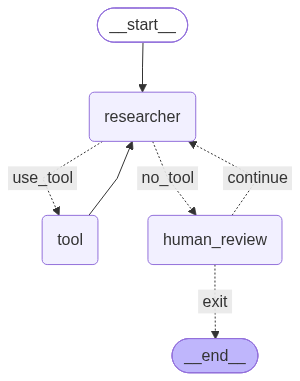

In [67]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


async def researcher_node(state: AgentState) -> dict:
    """yo this is the researcher agent!"""

    system_prompt = SystemMessage("""
        You are a research and writing assistant. Help the user create and refine a high-quality draft based on their request.
        Use the available tools when research or verification is needed. Do not invent facts or sources.
        When the user provides feedback, incorporate it into the current draft while preserving useful context from previous work.
    """)

    response: AIMessage = await llm.ainvoke([system_prompt, *state["messages"]])

    print(f"Messages getting to AI [{len(state['messages'])}]: ")
    for msg in state["messages"]:
        print(f"\t {msg}")

    return {"messages": [response]}


def human_review_node(state: AgentState) -> dict:
    feedback = interrupt("Provide feedback: ")
    return {"messages": [HumanMessage(feedback)]}


async def should_exit(state: AgentState) -> Literal['exit', 'continue']:
    system_prompt = SystemMessage("""
        Decide whether the user wants another revision.

        Reply with exactly one word:
        continue — if the user wants changes
        exit — if the user is satisfied

        Output only: continue or exit.
    """)
    last_msg = state["messages"][-1]

    if not isinstance(last_msg, HumanMessage):
        return "exit"

    referee_response: RefereeResponse = await referee_llm.ainvoke(
        [system_prompt, last_msg]
    )  # type: ignore
    decision: str = referee_response.decision
    print(f"[DEBUG] referee decision: {decision}")

    if decision == "exit":
        return "exit"
    elif decision == "continue":
        return "continue"
    else:
        raise ValueError(
            f"Referee responded with {decision} which is invalid, only supports [exit, continue]"
        )


def should_use_tool(state: AgentState) -> Literal['use_tool', 'no_tool']:
    last_msg = state["messages"][-1]

    if isinstance(last_msg, AIMessage) and last_msg.tool_calls:
        return "use_tool"
    else:
        return "no_tool"


graph = StateGraph(AgentState)

# Nodes
graph.add_node("researcher", researcher_node)
graph.add_node("tool", ToolNode(tools))
graph.add_node("human_review", human_review_node)

graph.add_edge(START, "researcher")
graph.add_conditional_edges(
    "researcher",
    should_use_tool,
    {
        "use_tool": "tool",
        "no_tool": "human_review",
    },
)

graph.add_conditional_edges(
    "human_review",
    should_exit,
    {
        "exit": END,
        "continue": "researcher",
    },
)

graph.add_edge("tool", "researcher")

app = graph.compile(checkpointer=MemorySaver())
app

In [68]:
config = RunnableConfig(configurable={"thread_id": "main2"})

prompt = HumanMessage(input("Enter Initial Prompt: "))
result = await app.ainvoke({"messages": [prompt]}, config=config)

while "__interrupt__" in result:
    print(f"Agent Response: {result['messages'][-1].content}")
    feedback = input(result["__interrupt__"][0].value)
    result = await app.ainvoke(Command(resume=feedback), config=config)

print(f"Final response: {result['messages'][-1].content}")

Messages getting to AI [1]: 
	 content='hey!' additional_kwargs={} response_metadata={} id='92dd8061-92dd-496f-a542-946aaeb3131f'
Agent Response: Hello! I'm here to help you with your research, writing, or creative projects. What would you like to work on today?
[DEBUG] referee decision: continue
Messages getting to AI [3]: 
	 content='hey!' additional_kwargs={} response_metadata={} id='92dd8061-92dd-496f-a542-946aaeb3131f'
	 content="Hello! I'm here to help you with your research, writing, or creative projects. What would you like to work on today?" additional_kwargs={} response_metadata={'model': 'huihui_ai/qwen3.5-abliterated:0.8b', 'created_at': '2026-09-05T16:32:48.7070956Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3865356600, 'load_duration': 3146500, 'prompt_eval_count': 407, 'prompt_eval_duration': 2706479000, 'eval_count': 28, 'eval_duration': 1133927000, 'logprobs': None, 'model_name': 'huihui_ai/qwen3.5-abliterated:0.8b', 'model_provider': 'ollama'} id='lc_run